In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
df=pd.read_csv("/home/user/Downloads/cleaned.csv")

checking churn balanced or not

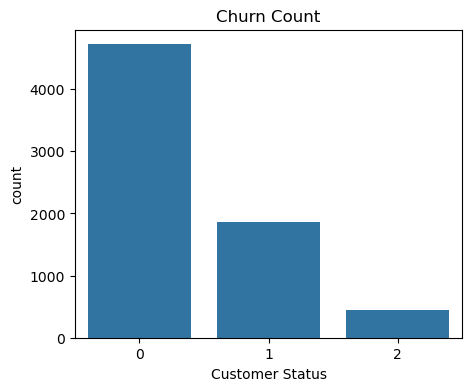

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x="Customer Status", data=df)
plt.title("Churn Count")
plt.show()

churn is not balanced .

so we have to find reasons for a churn.


lets check

-- tenure in months("how many months will they use")

----monthly charge("how much they charge per month")

----totalcharge("total charge = monthly charge* tenure")

----total extra data charges("monthly data + extra data---charge")

----total long distance charges("other states or countries phone call takes more charge than local")


now i am checking how the data was by using box plot

Comparing the numerical data with churn..

--how monthly charge of customers of churn vs no churn.

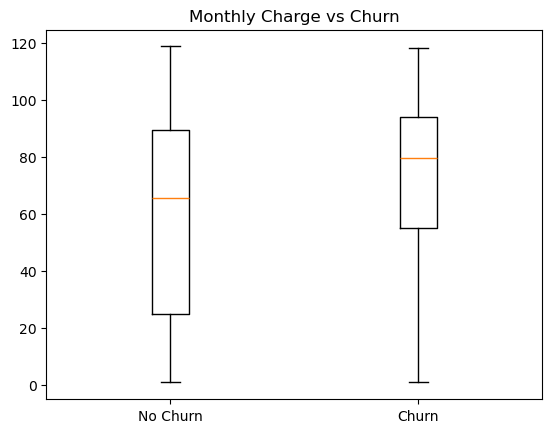

In [11]:
group0 = df[df['Customer Status'] == 0]['Monthly Charge']
group1 = df[df['Customer Status'] == 1]['Monthly Charge']
plt.boxplot([group0, group1])
plt.xticks([1,2], ['No Churn', 'Churn'])
plt.title("Monthly Charge vs Churn")
plt.show()

from the above graph we can say that

median of churn > median of not churn

so the customers who pay high monthly charges are more likely to churn.

Now see Tenure and Churn

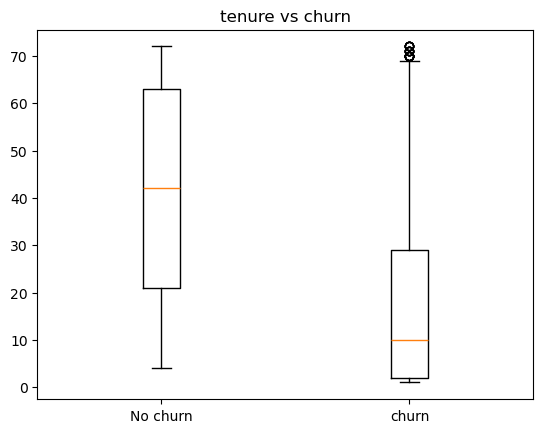

In [12]:
group_0=df[df["Customer Status"]==0]["Tenure in Months"]
group_1=df[df["Customer Status"]==1]["Tenure in Months"]
plt.boxplot([group_0,group_1])
plt.xticks([1,2],['No churn','churn'])
plt.title("tenure vs churn")
plt.show()

From the above Box Plot we can say having low tenure Customers can churn more.

we can see above in churn boxplot median is very low.Customers who stays less tenure can have chances to churn..

having outliers in churn means the customers who stays for more tenure also has chance to churn.

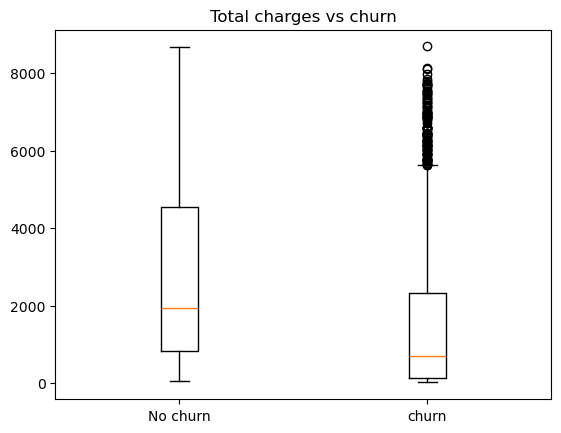

In [13]:
group_0=df[df["Customer Status"]==0]["Total Charges"]
group_1=df[df["Customer Status"]==1]["Total Charges"]
plt.boxplot([group_0,group_1])
plt.xticks([1,2],['No churn','churn'])
plt.title("Total charges vs churn")
plt.show()

median of churn < median of no churn..but churn group has extreme outlies 

that means

---most churn customers are new.

---few long term customers leave unexpectedly.



Now I am checking  based on contract type

grouping contract columns and finding their average

calculating churn rate for contract

In [14]:
monthtomonth_churn=df[df['Contract_Month-to-Month']==1]['Customer Status'].mean()
one_year_churn=df[df['Contract_One Year']==1]['Customer Status'].mean()
two_year_churn=df[df['Contract_Two Year']==1]['Customer Status'].mean()
print(monthtomonth_churn,one_year_churn,two_year_churn)

0.6844875346260387 0.13806451612903226 0.048858204992033985


PLotting in Bargraph

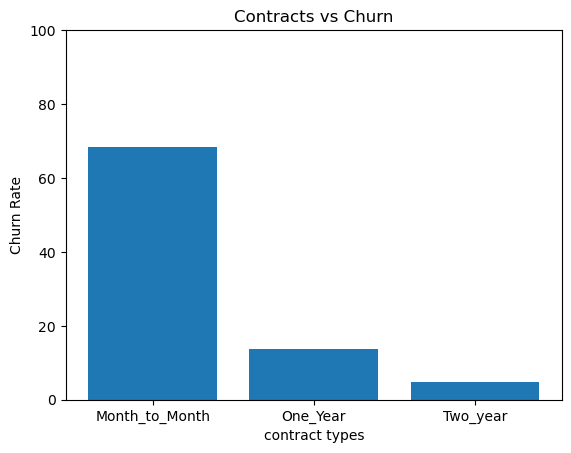

In [15]:
contracts = ['Month_to_Month','One_Year','Two_year']
churn_mean = [monthtomonth_churn*100, one_year_churn*100, two_year_churn*100]

plt.bar(contracts, churn_mean)
plt.title("Contracts vs Churn")
plt.ylabel("Churn Rate")
plt.xlabel("contract types")
plt.ylim(0,100)
plt.show()

From the above bargraph i Conclude that--

-->Month-to-Month Customers have high rate of churn percentage.

-->one_year contract customers have medium rate of churn percentage.

-->Two_years contract customers have very low churn rate percentage ,because they have long term plan.
***Finally*** 

***Because of short term plan also cause chances to churn***


Calculating Churn Rate for Payment Method

In [16]:
bank_withdrawal=df[df['Payment Method_Bank Withdrawal']==1]["Customer Status"].mean()
credit_card=df[df['Payment Method_Credit Card']==1]["Customer Status"].mean()
mailed_check=df[df['Payment Method_Mailed Check']==1]['Customer Status'].mean()


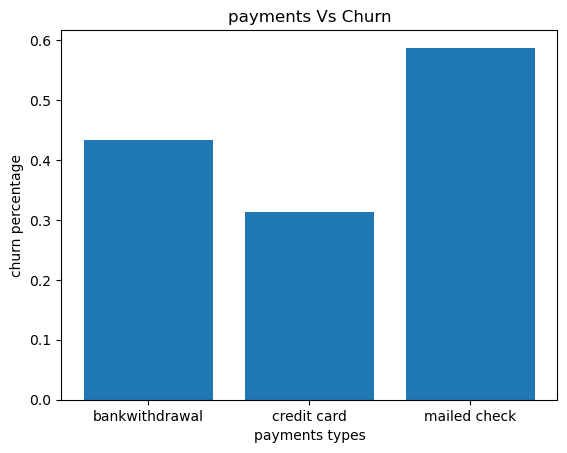

In [17]:
payments=['bankwithdrawal','credit card','mailed check']
payment_churn=[bank_withdrawal,credit_card,mailed_check]
plt.bar(payments,payment_churn)
plt.title("payments Vs Churn")
plt.xlabel("payments types")
plt.ylabel("churn percentage")
plt.show()

From the above bargraph I will conclude that 

-> By Using **Mailed check** customers will **churn more**...because it is a physical process it takes more time.

->After Mailed check Customers will churn more by using BankWithDrawal.

->By Using **Credit Card** Customers will **churn low**.Beacause it will cut money Automatically.

Now Checking Internet Service and Phone Service.

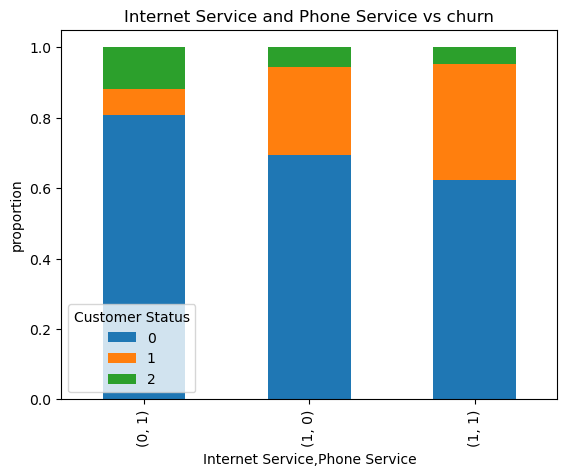

In [18]:
pd.crosstab([df['Internet Service'],df['Phone Service']],df['Customer Status'],normalize="index").plot(kind="bar",stacked=True)
plt.title("Internet Service and Phone Service vs churn")
plt.ylabel('proportion')
plt.show()

0->Stayed

1->churn

2-> joined

Customers with only **phone service** have the **lowest churn**.

Customers with **internet service** show **higher churn**.

Customers using **both internet and phone services** have the **highest churn** proportion.

**Extra Services**

In [19]:
services=['Online Security','Online Backup','Device Protection Plan','Premium Tech Support','Streaming TV','Streaming Movies','Streaming Music','Unlimited Data']
service_rate=[]
for service in services:
    rate =df[service].sum()
    service_rate.append(rate)
service_rate


[2019,
 2429,
 3093.4399999999996,
 2608.62,
 3454.7400000000002,
 3495.0,
 3174.7000000000007,
 6057.36]

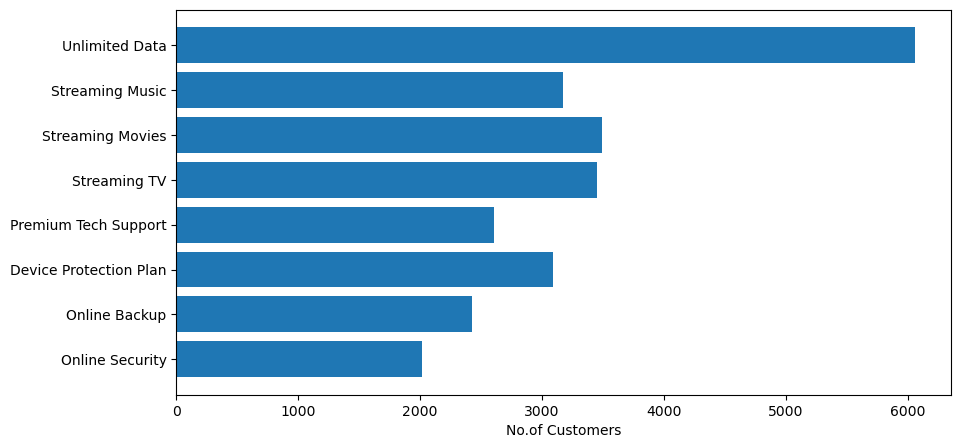

In [20]:
plt.figure(figsize=(10,5))
plt.barh(services,service_rate)
#plt.xticks(rotation=45)
plt.xlabel("No.of Customers")
#plt.ylim(0,50)
plt.show()

The Above Barchart shows how many customers utilizing Extra Services

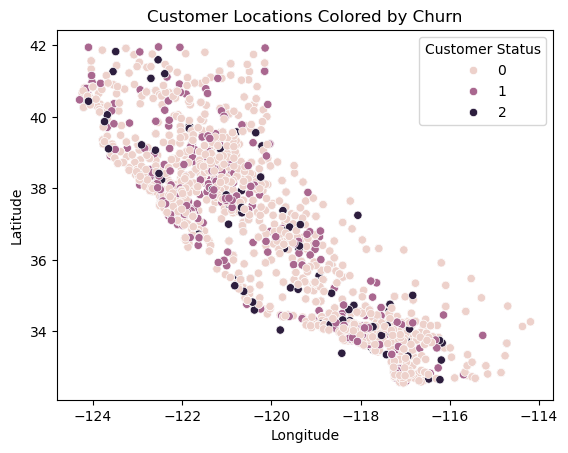

In [21]:


sns.scatterplot(x='Longitude',
                y='Latitude',
                hue='Customer Status',
                data=df)

plt.title("Customer Locations Colored by Churn")
plt.show()

-->Dot point represents one customer.

-->Most of the points are light purple in above graph that means customers didn't churn more in above graph.

-->medium purple dot indicated churn.churned customers exists along all latituade and longitude.

-->dark purple dot indicates joined customers.

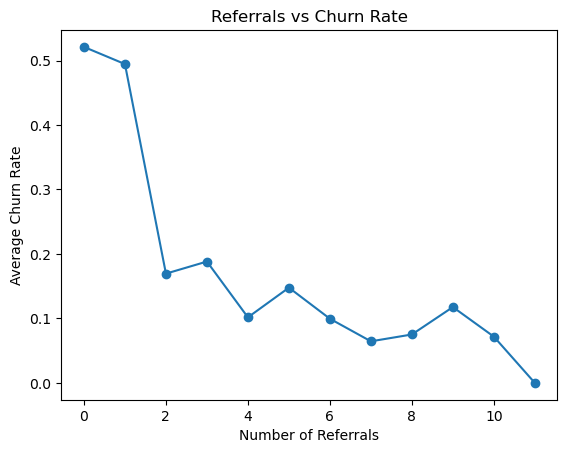

In [22]:
referral_churn = df.groupby('Number of Referrals')['Customer Status'].mean()

referral_churn.plot(marker='o')
plt.title("Referrals vs Churn Rate")
plt.ylabel("Average Churn Rate")
plt.show()

-->churn decreases when no of referrals increases..

--> when we refer to someone new customers will like to join.In this way we can get more customers and reduce the churn count.

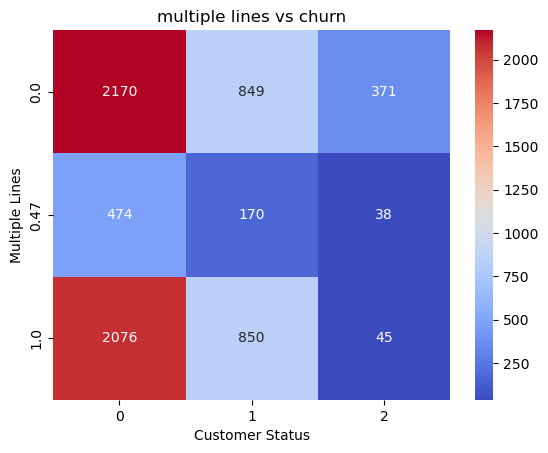

In [23]:
multi_table=pd.crosstab(df['Multiple Lines'],df['Customer Status'])
sns.heatmap(multi_table,annot=True,fmt='d',cmap='coolwarm')
plt.title("multiple lines vs churn")
plt.show()

Heat Map Shows the relation Between Multiple Lines subscription and churn.


-->Customers without multiple lines(0.0)

2170-->not churn

849-->churn

371-->joined

--->Customers with multiple lines(1.0)

474-->not churn

170-->churn

38-->joined

--->customers with no phone service(0.47)

2076-->not churn

850-->churn

45-->joined

From Above I observed that Multiple Lines Doesn't Effect Churn.

Having Equal Churn Difference.

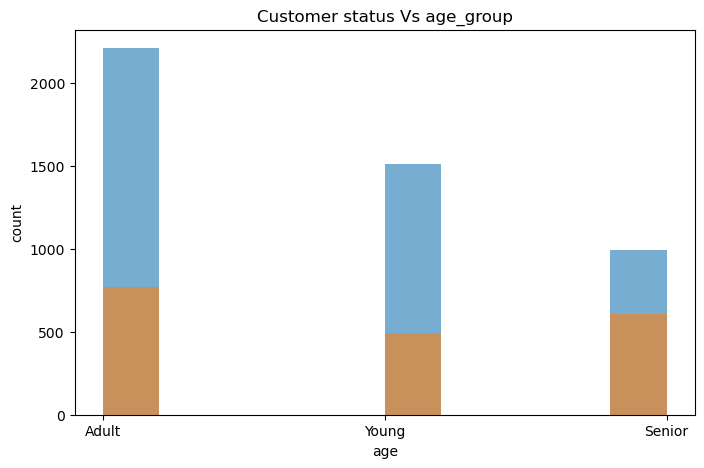

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df[df['Customer Status']==0]['age_group'],alpha=0.6)
plt.hist(df[df['Customer Status']==1]['age_group'],alpha=0.6)
plt.title("Customer status Vs age_group")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

By Bining Age COlumn :

                      18-35-->young
   
                       35-60-->adult

                       60-100-->senior

Based on above Histogram churn not effects by age

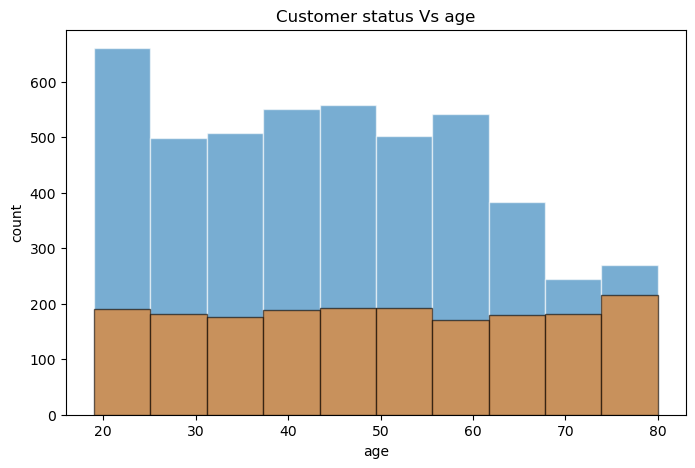

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df[df['Customer Status']==0]['Age'],alpha=0.6,bins=10,edgecolor='white')
plt.hist(df[df['Customer Status']==1]['Age'],alpha=0.6,bins=10,edgecolor='black')
plt.title("Customer status Vs age")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

Above Histogram Shows Age Distribution By not Binning.

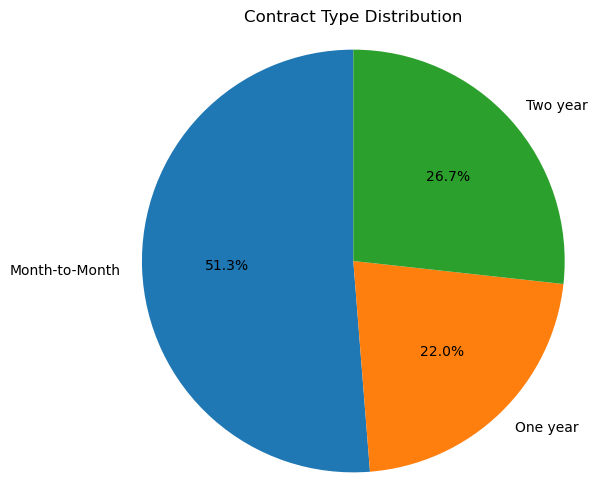

In [26]:

contract_counts = [df['Contract_Month-to-Month'].sum(),df['Contract_One Year'].sum(),df['Contract_Two Year'].sum()]

labels = ['Month-to-Month', 'One year', 'Two year']

plt.figure(figsize=(6,6))
plt.pie(contract_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Contract Type Distribution")
plt.axis('equal')
plt.show()

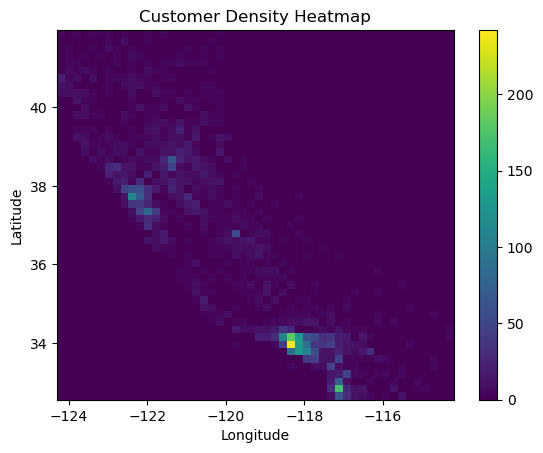

In [27]:


plt.hist2d(df['Longitude'], df['Latitude'], bins=50)
plt.colorbar()

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Customer Density Heatmap")
plt.show()

Most of the map is dark (low density)

Some small bright areas (yellow/green)

 This means customers are concentrated in specific regions, not spread equally.

 Longitude ≈ -118

Latitude ≈ 34

This is the brightest yellow region.

This indicates maximum number of customers in that area.

Text(0, 0.5, 'Monthly Long Distance Charges')

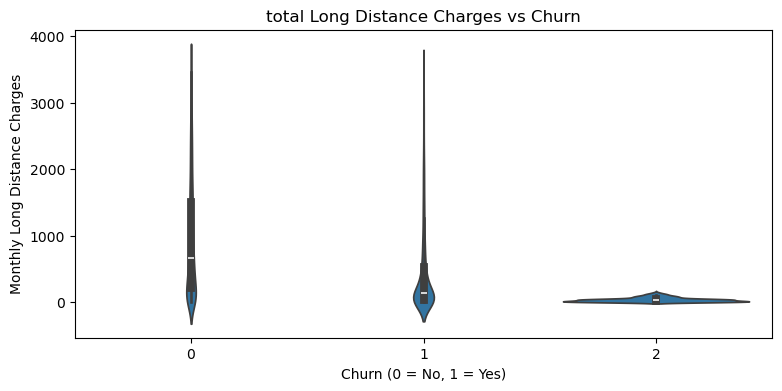

In [28]:
plt.figure(figsize=(9,4))

sns.violinplot(x='Customer Status',
               y='Total Long Distance Charges',
               data=df)

plt.title("total Long Distance Charges vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Long Distance Charges")



Width (fat area) → more customers in that range

Thin area → fewer customers

Height → range of values

Class 0 (Stayed)

Wide distribution

Charges spread from low → very high (~4000)

Many customers with different usage levels

Stable customers have varied usage


Class 1 (Churned)

Also wide but slightly different shape

Many customers have lower to medium charges

Some high-value customers also churn

Churn is not only high spenders — even low users leave

Class 2 (Joined)

Very narrow distribution

Mostly low charges

New customers:

Haven’t used services much yet
So charges are low

**for 2nd plot**

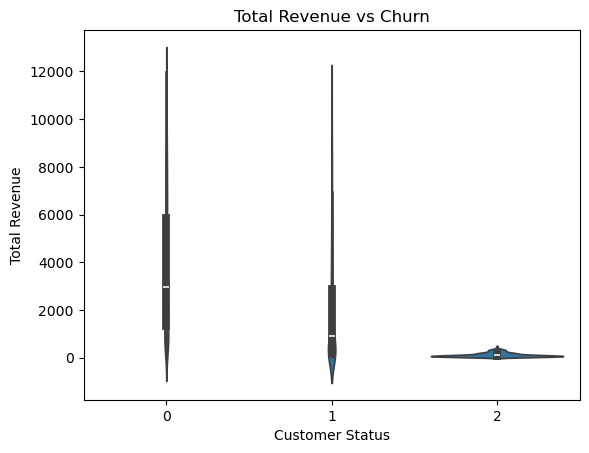

In [29]:

sns.violinplot(x='Customer Status', y='Total Revenue', data=df)
plt.title("Total Revenue vs Churn")
plt.show()
plt.show()

In [30]:
df['Total Revenue'].max()

11979.34

Class 0 (Stayed Customers)

Very wide distribution

Revenue ranges from low → very high (~13,000)

Many customers in mid to high revenue range

 These customers:

Stay longer

Generate high revenue

Class 1 (Churned Customers)

Revenue mostly in low to medium range

Fewer high-value customers compared to class 0


 Insight:

Customers who churn usually generate less revenue

Some high-value customers also churn (thin upper tail)

Class 2 (Joined Customers)

Very narrow and low values

Revenue close to 0–500

Reason:

New customers → haven’t spent much yet

PAIR PLOT

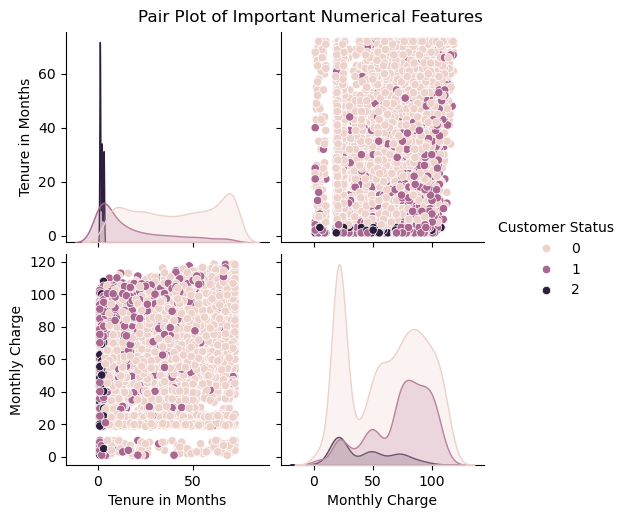

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select important columns
selected_columns = ['Tenure in Months',
                    'Monthly Charge',
                    'Customer Status']

sns.pairplot(df[selected_columns],
             hue='Customer Status',
             diag_kind='kde')

plt.suptitle("Pair Plot of Important Numerical Features", y=1.02)
plt.show()

**Plotting graphs side by side**

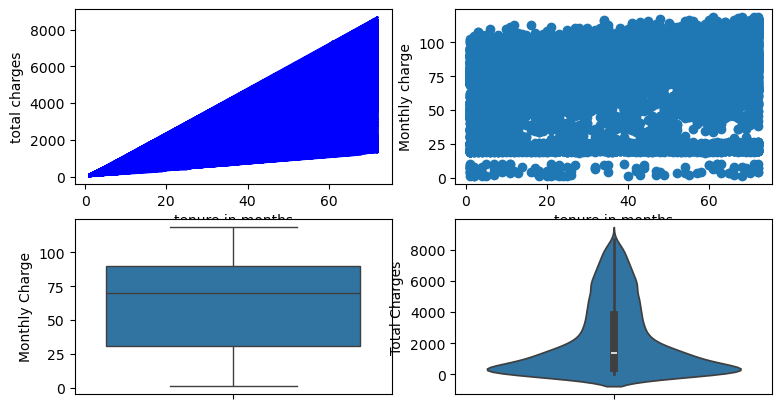

In [32]:
plt.figure(figsize=(9,5), dpi=100)

#  Line Plot
plt.subplot(2,2,1)
plt.plot( df['Tenure in Months'],df['Total Charges'],'b-')
plt.xlabel('tenure in months')
plt.ylabel('total charges')

#  Scatter Plot
plt.subplot(2,2,2)
plt.scatter(df['Tenure in Months'],df['Monthly Charge'])
plt.xlabel('tenure in months')
plt.ylabel('Monthly charge')

#  Box Plot
plt.subplot(2,2,3)
sns.boxplot(y=df['Monthly Charge'])


# Violin Plot
plt.subplot(2,2,4)
sns.violinplot(df['Total Charges'])
plt.show()

Area plot

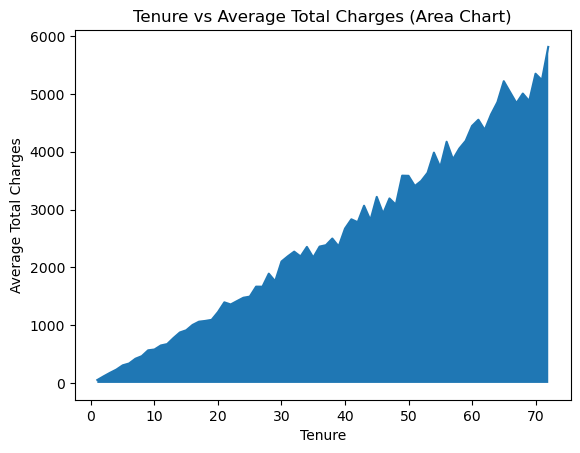

In [33]:

area_data = df.groupby('Tenure in Months')['Total Charges'].mean().reset_index()
plt.figure()
plt.plot(area_data['Tenure in Months'], area_data['Total Charges'])
plt.fill_between(area_data['Tenure in Months'], area_data['Total Charges'])

plt.xlabel("Tenure")
plt.ylabel("Average Total Charges")
plt.title("Tenure vs Average Total Charges (Area Chart)")
plt.show()

 Group by tenure and calculate average total charges
 
 high tenure-->high charges

**FOLIUM**

In [39]:
import folium
df = df.head(1000)
m = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=6
)
for i in range(len(df)):
    lat = df.iloc[i]['Latitude']
    lon = df.iloc[i]['Longitude']
    status = df.iloc[i]['Customer Status']
    color = 'red' if status == 1  else 'green'
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color=color,
        fill=True,
        fill_color=color
    ).add_to(m)
m.save("map.html")

Corrleation Heat Map

In [35]:
important_features = [
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "avg_monthly_spend",
    "spend_change",
    'high_bill',
    "Contract_Month-to-Month",
    'Customer Status',
    'Payment Method_Bank Withdrawal',
      'Payment Method_Mailed Check',
    
]

In [36]:
corr = df[important_features].corr()

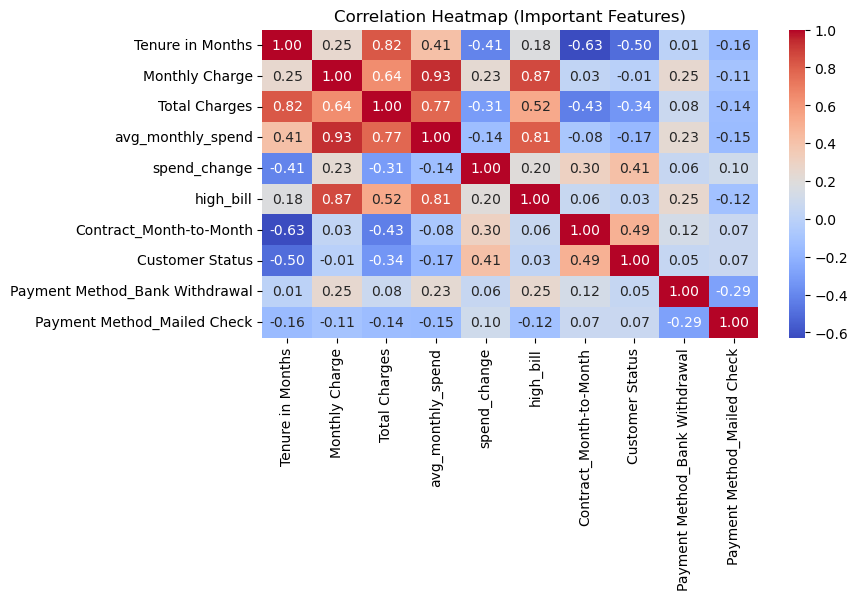

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Important Features)")
plt.show()

KDE Plot:
A KDE plot is a smoothed version of a histogram that shows the probability distribution of a continuous variable.

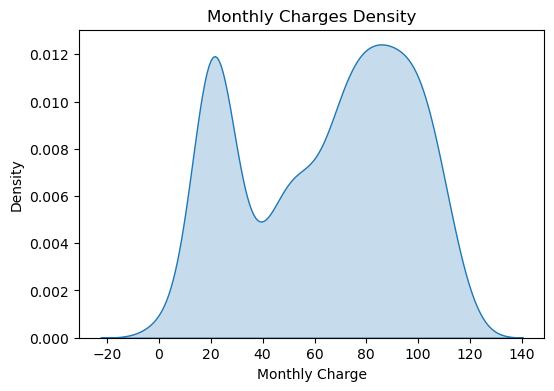

In [38]:
plt.figure(figsize=(6,4))
sns.kdeplot(df["Monthly Charge"], fill=True)
plt.title("Monthly Charges Density")
plt.show()